In [11]:
# ─── CELL 1: Install & Import ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded")

✅ Libraries loaded


In [12]:
# ─── CELL 2: Load Dataset ────────────────────────────────────────────────────
# Make sure your CSV file is in the same folder as this notebook
# PaySim CSV is usually named: PS_20174392719_1491204439457_log.csv
# Rename it to paysim.csv for convenience

df = pd.read_csv('paysim.csv')   # update filename if different

print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Shape       : (341829, 11)
Columns     : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 3 rows:
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0      0.0             0.0  
1  M2044282225             0.0             0.0      0.0             0.0  
2   C553264065             0.0             0.0      1.0             0.0  


In [13]:
# ─── CELL 3: Basic Info ──────────────────────────────────────────────────────
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
print(df.describe())

=== DATA TYPES ===
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
isFlaggedFraud    float64
dtype: object

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64

=== BASIC STATS ===
                step        amount  oldbalanceOrg  newbalanceOrig  \
count  341829.000000  3.418290e+05   3.418290e+05    3.418290e+05   
mean       11.982556  1.745974e+05   8.974672e+05    9.167459e+05   
std         2.868772  2.933899e+05   2.919070e+06    2.956295e+06   
min         1.000000  3.000000e-01   0.000000e+00    0.000000e+00   
25%        10.000000  1.305281e+04   0.000000e+00    0.000

=== FRAUD DISTRIBUTION ===
Legitimate : 341,635  (99.94%)
Fraudulent : 193  (0.06%)


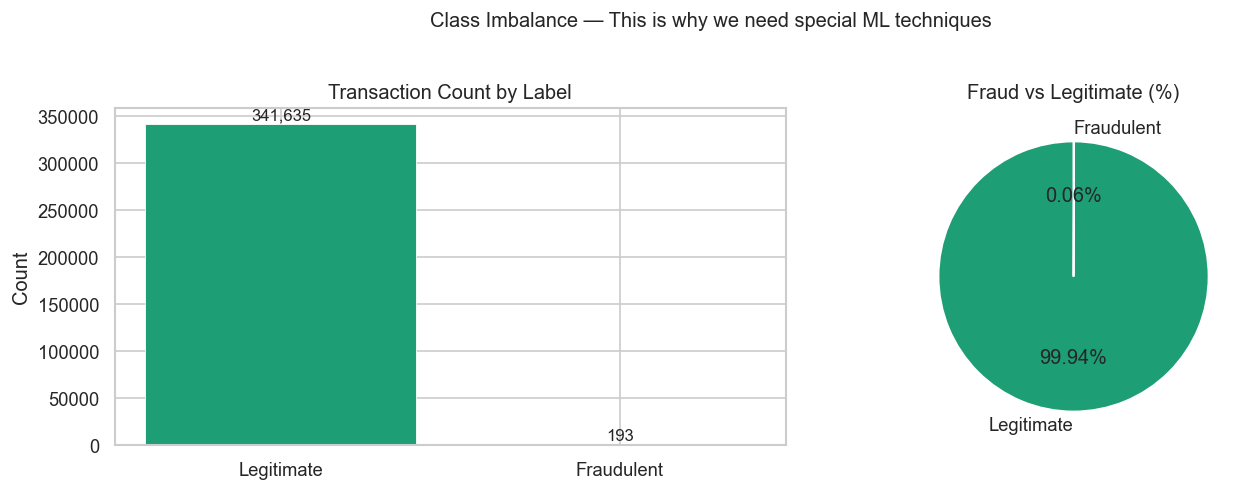

💡 Insight: Massive class imbalance — only ~0.13% fraud. We must handle this carefully.


In [14]:
# ─── CELL 4: Fraud Distribution ──────────────────────────────────────────────
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print("=== FRAUD DISTRIBUTION ===")
print(f"Legitimate : {fraud_counts[0]:,}  ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent : {fraud_counts[1]:,}  ({fraud_pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
            color=['#1D9E75', '#E24B4A'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Transaction Count by Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.2f%%', colors=['#1D9E75', '#E24B4A'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Fraud vs Legitimate (%)')

plt.suptitle('Class Imbalance — This is why we need special ML techniques',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('eda_fraud_distribution.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Massive class imbalance — only ~0.13% fraud. We must handle this carefully.")

=== TRANSACTION TYPES ===
type
CASH_OUT    121306
PAYMENT     116665
CASH_IN      73083
TRANSFER     28302
DEBIT         2473
Name: count, dtype: int64


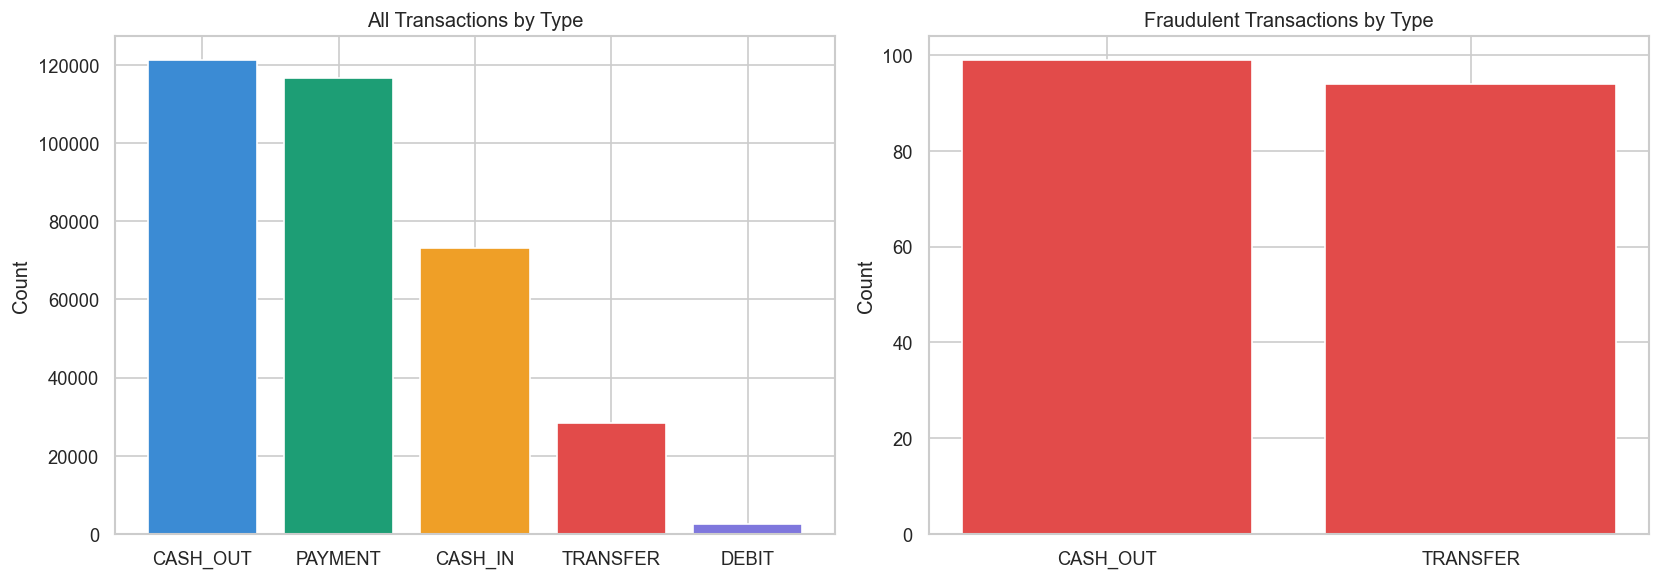

💡 Insight: Fraud only occurs in TRANSFER and CASH_OUT — never in PAYMENT or DEBIT!
   This alone is a massive feature for your model.


In [15]:
# ─── CELL 5: Transaction Types ───────────────────────────────────────────────
print("=== TRANSACTION TYPES ===")
print(df['type'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All transactions by type
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3B8BD4','#1D9E75','#EF9F27','#E24B4A','#7F77DD'],
            edgecolor='white')
axes[0].set_title('All Transactions by Type')
axes[0].set_ylabel('Count')

# Fraud by type
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
axes[1].bar(fraud_by_type.index, fraud_by_type.values,
            color='#E24B4A', edgecolor='white')
axes[1].set_title('Fraudulent Transactions by Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_transaction_types.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Fraud only occurs in TRANSFER and CASH_OUT — never in PAYMENT or DEBIT!")
print("   This alone is a massive feature for your model.")

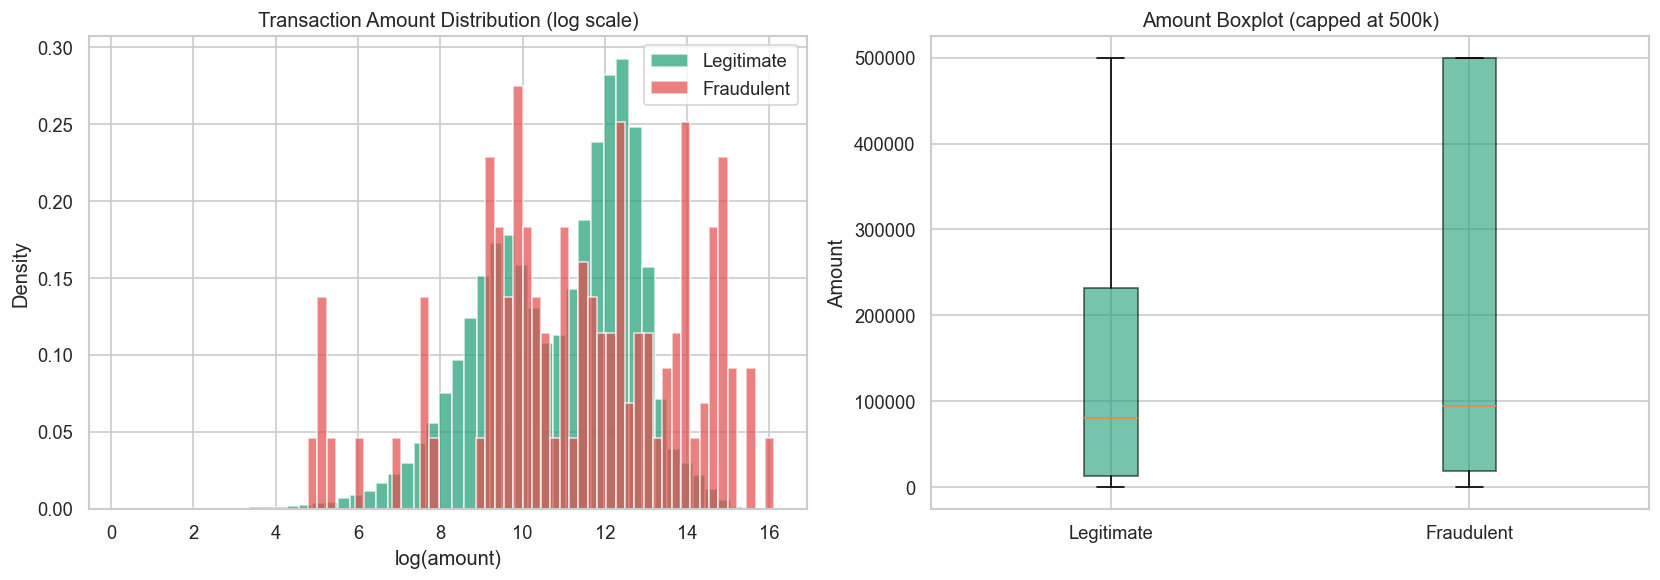

Avg legitimate amount : ₹174,265
Avg fraudulent amount : ₹764,152
💡 Insight: Fraudulent transactions tend to be much larger on average.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution (log scale)
axes[0].hist(np.log1p(df[df['isFraud']==0]['amount']), bins=50,
             color='#1D9E75', alpha=0.7, label='Legitimate', density=True)
axes[0].hist(np.log1p(df[df['isFraud']==1]['amount']), bins=50,
             color='#E24B4A', alpha=0.7, label='Fraudulent', density=True)
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('log(amount)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
fraud_labels = df['isFraud'].map({0: 'Legitimate', 1: 'Fraudulent'})
axes[1].boxplot(
    [df[df['isFraud']==0]['amount'].clip(upper=500000),
     df[df['isFraud']==1]['amount'].clip(upper=500000)],
    tick_labels=['Legitimate', 'Fraudulent'],
    patch_artist=True,
    boxprops=dict(facecolor='#1D9E75', alpha=0.6),
)
axes[1].set_title('Amount Boxplot (capped at 500k)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.savefig('eda_amount_distribution.png', bbox_inches='tight')
plt.show()

print(f"Avg legitimate amount : ₹{df[df['isFraud']==0]['amount'].mean():,.0f}")
print(f"Avg fraudulent amount : ₹{df[df['isFraud']==1]['amount'].mean():,.0f}")
print("💡 Insight: Fraudulent transactions tend to be much larger on average.")

In [17]:
# ─── CELL 7: Balance Analysis (KEY INSIGHT) ──────────────────────────────────
# In fraud, the origin balance is completely drained
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Flag: origin account fully emptied
df['orig_emptied'] = ((df['newbalanceOrig'] == 0) &
                      (df['oldbalanceOrg'] > 0)).astype(int)

print("=== ACCOUNTS EMPTIED ===")
emptied = df.groupby('isFraud')['orig_emptied'].mean() * 100
print(f"Legitimate transactions where account emptied : {emptied[0]:.1f}%")
print(f"Fraudulent transactions where account emptied : {emptied[1]:.1f}%")
print("💡 Huge signal! Fraudsters drain the account completely.")

=== ACCOUNTS EMPTIED ===
Legitimate transactions where account emptied : 22.6%
Fraudulent transactions where account emptied : 93.8%
💡 Huge signal! Fraudsters drain the account completely.


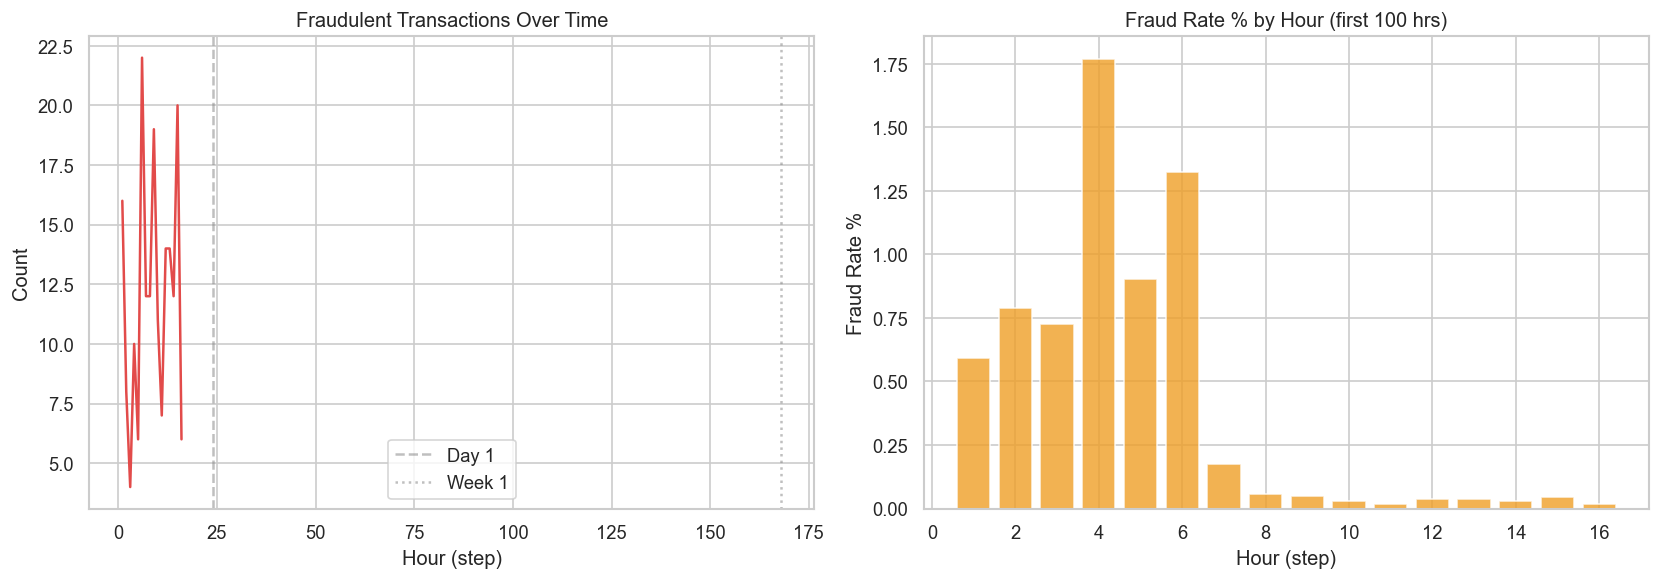

💡 Insight: Fraud spikes at certain time periods — time is a useful feature.


In [19]:
# ─── CELL 8: Time Analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud over time (step = hour)
fraud_over_time = df[df['isFraud']==1]['step'].value_counts().sort_index()
axes[0].plot(fraud_over_time.index, fraud_over_time.values,
             color='#E24B4A', linewidth=1.5)
axes[0].set_title('Fraudulent Transactions Over Time')
axes[0].set_xlabel('Hour (step)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=24, color='gray', linestyle='--', alpha=0.5, label='Day 1')
axes[0].axvline(x=168, color='gray', linestyle=':', alpha=0.5, label='Week 1')
axes[0].legend()

# Fraud rate by step (first 100 steps)
step_fraud = df[df['step'] <= 100].groupby('step')['isFraud'].mean() * 100
axes[1].bar(step_fraud.index, step_fraud.values, color='#EF9F27', alpha=0.8)
axes[1].set_title('Fraud Rate % by Hour (first 100 hrs)')
axes[1].set_xlabel('Hour (step)')
axes[1].set_ylabel('Fraud Rate %')

plt.tight_layout()
plt.savefig('eda_time_analysis.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Fraud spikes at certain time periods — time is a useful feature.")

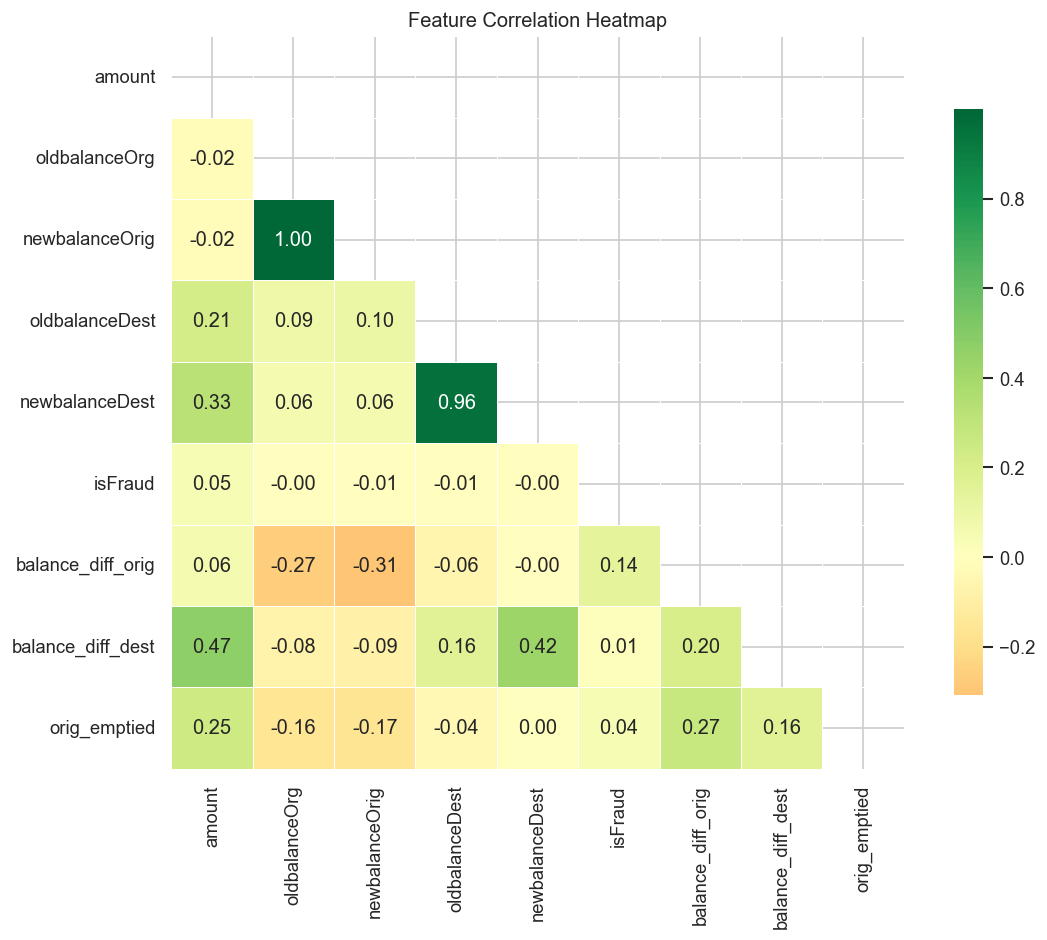

💡 Insight: orig_emptied and balance_diff_orig correlate well with isFraud.


In [20]:
# ─── CELL 9: Correlation Heatmap ─────────────────────────────────────────────
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud',
                'balance_diff_orig', 'balance_diff_dest', 'orig_emptied']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()
print("💡 Insight: orig_emptied and balance_diff_orig correlate well with isFraud.")

In [21]:
# ─── CELL 1: Import Libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("✅ Libraries loaded")
print("⚠️  If imblearn not installed, run: pip install imbalanced-learn")

✅ Libraries loaded
⚠️  If imblearn not installed, run: pip install imbalanced-learn


In [22]:
# ─── CELL 2: Load Data ───────────────────────────────────────────────────────
df = pd.read_csv('paysim.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")


✅ Data loaded: (341829, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [23]:
# ─── CELL 3: Drop Useless Columns ────────────────────────────────────────────
"""
WHY WE DROP THESE:
- nameOrig, nameDest : string IDs — XGBoost/IF can't use strings
                       We save them separately for GNN
- isFlaggedFraud     : only catches 16 out of 8213 frauds — useless
"""

# Save name columns for GNN before dropping
df_names = df[['nameOrig', 'nameDest', 'isFraud']].copy()

# Drop from main df
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

print(f"✅ Dropped useless columns")
print(f"Remaining columns: {list(df.columns)}")



✅ Dropped useless columns
Remaining columns: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


In [24]:
# ─── CELL 4: Encode 'type' Column ────────────────────────────────────────────
"""
WHY WE ENCODE:
- ML models only understand numbers, not strings like 'TRANSFER'
- We use One-Hot Encoding so the model treats each type independently
- Avoids false ordering (e.g. TRANSFER=3 > PAYMENT=2 is meaningless)
"""

# One-hot encode 'type'
type_dummies = pd.get_dummies(df['type'], prefix='type')
df = pd.concat([df.drop(columns=['type']), type_dummies], axis=1)

print("✅ One-hot encoded 'type' column")
print(f"New type columns: {[c for c in df.columns if c.startswith('type_')]}")
print(f"Dataset shape after encoding: {df.shape}")

✅ One-hot encoded 'type' column
New type columns: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
Dataset shape after encoding: (341829, 12)


In [25]:

# ─── CELL 5: Feature Engineering ─────────────────────────────────────────────
"""
WHY WE ENGINEER FEATURES:
Raw columns don't fully capture fraud patterns.
We create new columns that directly represent those patterns.
This dramatically improves model accuracy.
"""

# Feature 1: orig_emptied
# Account balance fully drained to zero after transaction
# This is the #1 fraud signal in the dataset
df['orig_emptied'] = (
    (df['newbalanceOrig'] == 0) &
    (df['oldbalanceOrg'] > 0)
).astype(int)

# Feature 2: dest_unchanged
# Receiver's balance didn't change despite receiving money
# Classic money laundering — money passed through immediately
df['dest_unchanged'] = (
    (df['oldbalanceDest'] == df['newbalanceDest']) &
    (df['amount'] > 0)
).astype(int)

# Feature 3: amount_vs_orig_balance
# What fraction of sender's balance was transferred?
# Fraud: usually 100% (full drain). Legit: usually partial
df['amount_vs_orig_balance'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# Feature 4: balance_diff_orig
# How much did the sender's balance drop?
# Should equal amount if legitimate. Mismatch = suspicious
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Feature 5: balance_diff_dest
# How much did the receiver's balance increase?
# If this doesn't match amount received = money laundering
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

# Feature 6: amount_mismatch
# Difference between what was sent and what receiver actually got
# In legit transactions this should be 0 or very small
df['amount_mismatch'] = abs(df['amount'] - df['balance_diff_dest'])

# Feature 7: log_amount
# Log transformation of amount to reduce skew
# Makes the distribution more normal for better model performance
df['log_amount'] = np.log1p(df['amount'])

print("✅ Engineered 7 new features")
print(f"New feature columns: orig_emptied, dest_unchanged, amount_vs_orig_balance,")
print(f"                     balance_diff_orig, balance_diff_dest, amount_mismatch, log_amount")

# Quick validation — fraud vs legit for top features
print("\n=== FEATURE VALIDATION ===")
for feat in ['orig_emptied', 'dest_unchanged']:
    vals = df.groupby('isFraud')[feat].mean() * 100
    print(f"\n{feat}:")
    print(f"  Legitimate : {vals[0]:.1f}%")
    print(f"  Fraudulent : {vals[1]:.1f}%")

✅ Engineered 7 new features
New feature columns: orig_emptied, dest_unchanged, amount_vs_orig_balance,
                     balance_diff_orig, balance_diff_dest, amount_mismatch, log_amount

=== FEATURE VALIDATION ===

orig_emptied:
  Legitimate : 22.6%
  Fraudulent : 93.8%

dest_unchanged:
  Legitimate : 36.1%
  Fraudulent : 40.4%


In [27]:
# ─── CELL 6: Clip Outliers ───────────────────────────────────────────────────
"""
WHY WE CLIP:
Some amounts are extremely large (outliers).
Extreme values confuse models and slow training.
We cap at the 99.9th percentile — keeping real patterns
but removing extreme noise.
"""

clip_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
             'oldbalanceDest', 'newbalanceDest',
             'balance_diff_orig', 'balance_diff_dest', 'amount_mismatch']

for col in clip_cols:
    upper = df[col].quantile(0.999)
    df[col] = df[col].clip(upper=upper)

print("✅ Clipped outliers at 99.9th percentile")

✅ Clipped outliers at 99.9th percentile


In [28]:
# ─── CELL 7: Define Feature Sets ─────────────────────────────────────────────
"""
We define separate feature sets for each model.
XGBoost and Isolation Forest use the same features.
GNN uses a completely different graph structure (built in Cell 9).
"""

FEATURE_COLS = [
    # Raw numeric features
    'step', 'amount', 'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    # One-hot encoded type
    'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT',
    'type_PAYMENT', 'type_TRANSFER',
    # Engineered features
    'orig_emptied', 'dest_unchanged',
    'amount_vs_orig_balance',
    'balance_diff_orig', 'balance_diff_dest',
    'amount_mismatch'
]

TARGET_COL = 'isFraud'

# Keep only existing columns (in case some type columns are missing)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"✅ Feature set defined")
print(f"Total features : {len(FEATURE_COLS)}")
print(f"Feature list   : {FEATURE_COLS}")
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Fraud   : {y.sum():,} ({y.mean()*100:.2f}%)")

✅ Feature set defined
Total features : 18
Feature list   : ['step', 'amount', 'log_amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'orig_emptied', 'dest_unchanged', 'amount_vs_orig_balance', 'balance_diff_orig', 'balance_diff_dest', 'amount_mismatch']

X shape : (341829, 18)
y shape : (341829,)
Fraud   : 193.0 (0.06%)


In [32]:
# ─── FIX: Check and clean NaN values ─────────────────────────────────────────

print("=== NaN CHECK BEFORE SPLIT ===")
print(f"NaNs in X : {X.isnull().sum().sum()}")
print(f"NaNs in y : {y.isnull().sum()}")

# Drop rows where y (isFraud) is NaN
nan_mask = y.isnull()
if nan_mask.sum() > 0:
    print(f"⚠️  Dropping {nan_mask.sum()} rows with NaN in isFraud")
    X = X[~nan_mask]
    y = y[~nan_mask]

# Fill any NaN in X with 0
if X.isnull().sum().sum() > 0:
    print(f"⚠️  Filling NaN values in X with 0")
    X = X.fillna(0)

# Reset index to avoid index mismatch
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Confirm y only has 0 and 1
print(f"\nUnique values in y : {y.unique()}")
print(f"NaNs in X after fix: {X.isnull().sum().sum()}")
print(f"NaNs in y after fix: {y.isnull().sum()}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")
print("✅ Ready for train_test_split")

=== NaN CHECK BEFORE SPLIT ===
NaNs in X : 4
NaNs in y : 1
⚠️  Dropping 1 rows with NaN in isFraud

Unique values in y : [0. 1.]
NaNs in X after fix: 0
NaNs in y after fix: 0
Shape X: (341828, 18) | Shape y: (341828,)
✅ Ready for train_test_split


In [33]:
# ─── CELL 8: Train-Test Split + SMOTE ────────────────────────────────────────
"""
WHY TRAIN-TEST SPLIT:
- Train set (80%) : model learns from this
- Test set  (20%) : we evaluate model on unseen data
- stratify=y      : ensures same fraud % in both splits
 
WHY SMOTE:
- We have 99.87% legit vs 0.13% fraud
- Model would just predict 'not fraud' always
- SMOTE creates synthetic fraud samples to balance the training data
- We ONLY apply SMOTE to training data, never test data
  (test data must reflect real-world distribution)
"""
 
# Train-test split (stratified to maintain fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
 
print(f"✅ Train-Test Split done")
print(f"Train : {X_train.shape} | Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test  : {X_test.shape}  | Fraud: {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")
 
# Apply SMOTE to training data only
print("\nApplying SMOTE... (this may take 1-2 minutes on large data)")
 
# Use a sample for speed if full dataset is too large
# Remove the sample line below if you have >16GB RAM
SAMPLE_SIZE = 200000
if len(X_train) > SAMPLE_SIZE:
    # Stratified sample to keep fraud cases
    fraud_train   = X_train[y_train == 1]
    legit_train   = X_train[y_train == 0].sample(
                        n=SAMPLE_SIZE - len(fraud_train), random_state=42)
    X_train_s     = pd.concat([fraud_train, legit_train])
    y_train_s     = pd.concat([y_train[y_train==1],
                                y_train[y_train==0].sample(
                                    n=SAMPLE_SIZE - len(fraud_train),
                                    random_state=42)])
    print(f"  Sampled {SAMPLE_SIZE:,} rows for SMOTE (keeping all {len(fraud_train)} fraud cases)")
else:
    X_train_s = X_train
    y_train_s = y_train
 
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_s, y_train_s)
 
print(f"✅ SMOTE applied")
print(f"After SMOTE - Train: {X_train_bal.shape}")
print(f"After SMOTE - Fraud: {y_train_bal.sum():,} ({y_train_bal.mean()*100:.1f}%)")

✅ Train-Test Split done
Train : (273462, 18) | Fraud: 154.0 (0.06%)
Test  : (68366, 18)  | Fraud: 39.0  (0.06%)

Applying SMOTE... (this may take 1-2 minutes on large data)
  Sampled 200,000 rows for SMOTE (keeping all 154 fraud cases)
✅ SMOTE applied
After SMOTE - Train: (399692, 18)
After SMOTE - Fraud: 199,846.0 (50.0%)


In [34]:
# ─── CELL 9: Scale Features ──────────────────────────────────────────────────
"""
WHY WE SCALE:
- XGBoost doesn't strictly need scaling but it helps convergence
- Isolation Forest IS sensitive to scale — large amounts would dominate
- GNN node features also need to be on similar scales
- StandardScaler: mean=0, std=1 for each feature
- We fit scaler ONLY on training data, then transform both train+test
  (prevents data leakage)
"""
 
scaler = StandardScaler()
 
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)
 
# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)
 
print("✅ Features scaled with StandardScaler")
print(f"Train scaled shape : {X_train_scaled.shape}")
print(f"Test scaled shape  : {X_test_scaled.shape}")

✅ Features scaled with StandardScaler
Train scaled shape : (399692, 18)
Test scaled shape  : (68366, 18)


In [35]:
# ─── CELL 10: Build GNN Graph Data ───────────────────────────────────────────
"""
WHY WE BUILD A GRAPH:
XGBoost and Isolation Forest look at each row independently.
GNN looks at RELATIONSHIPS between accounts.
A fraudster's account looks innocent alone — but connected
to 50 other accounts draining to the same destination, the
ring becomes visible.
 
GRAPH STRUCTURE:
- Nodes : unique accounts (nameOrig + nameDest combined)
- Edges : transactions between them
- Node features : aggregated stats per account
- Edge features : transaction details
"""
 
print("Building GNN graph data...")
 
# Use original df with names
df_graph = df.copy()
df_graph['nameOrig'] = df_names['nameOrig']
df_graph['nameDest']  = df_names['nameDest']

Building GNN graph data...


In [36]:

 
# ── Node feature engineering ──────────────────────────────────────────────────
# For each account (as sender), compute aggregated stats
sender_stats = df_graph.groupby('nameOrig').agg(
    total_sent        = ('amount', 'sum'),
    avg_sent          = ('amount', 'mean'),
    num_sent          = ('amount', 'count'),
    max_sent          = ('amount', 'max'),
    orig_emptied_cnt  = ('orig_emptied', 'sum'),
    fraud_sent        = ('isFraud', 'sum')
).reset_index().rename(columns={'nameOrig': 'account'})
 
# For each account (as receiver), compute aggregated stats
receiver_stats = df_graph.groupby('nameDest').agg(
    total_received    = ('amount', 'sum'),
    avg_received      = ('amount', 'mean'),
    num_received      = ('amount', 'count'),
    max_received      = ('amount', 'max'),
    dest_unchanged_cnt= ('dest_unchanged', 'sum'),
    fraud_received    = ('isFraud', 'sum')
).reset_index().rename(columns={'nameDest': 'account'})
 
# Merge sender and receiver stats into one node table
node_features = pd.merge(sender_stats, receiver_stats,
                          on='account', how='outer').fillna(0)
 
# Is this account involved in any fraud?
node_features['is_fraud_node'] = (
    (node_features['fraud_sent'] > 0) |
    (node_features['fraud_received'] > 0)
).astype(int)
 
# Assign numeric IDs to each node
node_features['node_id'] = range(len(node_features))
node_id_map = dict(zip(node_features['account'], node_features['node_id']))
 
print(f"✅ Node features built")
print(f"Total nodes (unique accounts) : {len(node_features):,}")
print(f"Fraud nodes                   : {node_features['is_fraud_node'].sum():,}")
 
# ── Edge feature engineering ───────────────────────────────────────────────────
# Use a sample for GNN (full 6M is too large for prelim round)
df_edges = df_graph.sample(n=min(100000, len(df_graph)), random_state=42)
 
edge_features = pd.DataFrame({
    'src'             : df_edges['nameOrig'].map(node_id_map),
    'dst'             : df_edges['nameDest'].map(node_id_map),
    'amount'          : df_edges['amount'],
    'log_amount'      : df_edges['log_amount'],
    'step'            : df_edges['step'],
    'orig_emptied'    : df_edges['orig_emptied'],
    'dest_unchanged'  : df_edges['dest_unchanged'],
    'amount_mismatch' : df_edges['amount_mismatch'],
    'is_fraud_edge'   : df_edges['isFraud']
}).dropna()
 
print(f"✅ Edge features built")
print(f"Total edges (transactions) : {len(edge_features):,}")
print(f"Fraud edges                : {edge_features['is_fraud_edge'].sum():,}")

✅ Node features built
Total nodes (unique accounts) : 493,799
Fraud nodes                   : 384
✅ Edge features built
Total edges (transactions) : 100,000
Fraud edges                : 49.0


In [ ]:
# ─── CELL 11: Save All Preprocessed Data ─────────────────────────────────────
"""
We save everything so Steps 4, 5, 6 can load directly
without re-running preprocessing every time.
"""
 
import joblib
 
# Save for XGBoost and Isolation Forest
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv',   index=False)
pd.Series(y_train_bal, name='isFraud').to_csv('y_train.csv', index=False)
pd.Series(y_test,      name='isFraud').to_csv('y_test.csv',  index=False)
 
# Save unscaled test set for XGBoost (it works better without scaling)
X_test.to_csv('X_test_raw.csv', index=False)
X_train_bal.to_csv('X_train_raw.csv', index=False)
 
# Save for GNN
node_features.to_csv('gnn_nodes.csv',  index=False)
edge_features.to_csv('gnn_edges.csv',  index=False)
 
# Save scaler for use in dashboard/deployment
joblib.dump(scaler, 'scaler.pkl')
 
print("✅ All files saved:")
print("   X_train.csv      → XGBoost / Isolation Forest training features (scaled)")
print("   X_test.csv       → XGBoost / Isolation Forest test features (scaled)")
print("   X_train_raw.csv  → XGBoost training features (unscaled)")
print("   X_test_raw.csv   → XGBoost test features (unscaled)")
print("   y_train.csv      → Training labels")
print("   y_test.csv       → Test labels")
print("   gnn_nodes.csv    → GNN node features")
print("   gnn_edges.csv    → GNN edge features")
print("   scaler.pkl       → Saved scaler for deployment")